# Beijing PM2.5 Data Regression
## Regression Track — Review 1

### Objective

The objective of this regression task is to predict the **PM2.5 level** from
meteorological data.

The dataset contains meteorological and pollution data from Beijing. Each measurement is described by meteorological features.

### Regression Algorithms Implemented

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor

### Evaluation Metrics

All models are evaluated using: **R² Score**, **RMSE**, **MAE**.
5-fold cross-validated R² is reported for the two best-performing models.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Dataset Loading and Audit

In [2]:
csv_path = PROJECT_ROOT / 'data' / 'beijing+pm2+5+data' / 'PRSA_data_2010.1.1-2014.12.31.csv'
df = pd.read_csv(csv_path)
print('Dataset shape:', df.shape)
feature_columns = [col for col in df.columns if col not in ['No', 'pm2.5', 'cbwd']]

Dataset shape: (43824, 13)


In [3]:
print('First 5 rows:')
display(df.head())

First 5 rows:


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## 2. Exploratory Data Analysis

- Dataset audit (shape, dtypes, target distribution, batch distribution)
- Descriptive statistics for all the features
- Missing values
- Duplicate records
- Outlier analysis (IQR for all the features)
- Target distribution
- Feature distributions (all the features)
- Correlation of all features with the target
- Correlation heatmap
- Feature-target scatter plots

### Dataset Audit

In [4]:
print('========== DATASET AUDIT ==========')
print('Shape:', df.shape)

========== DATASET AUDIT ==========
Shape: (43824, 13)


### Full Dataset Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


### Descriptive Statistics — All Features

Showing count, mean, std, min, 25th/50th/75th percentile, and max for every sensor feature.

In [6]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
No,43824.0,21912.500000,12651.043435,1.00,10956.75,21912.50,32868.25,43824.0
year,43824.0,2012.000000,1.413842,2010.00,2011.00,2012.00,2013.00,2014.0
month,43824.0,6.523549,3.448572,1.00,4.00,7.00,10.00,12.0
day,43824.0,15.727820,8.799425,1.00,8.00,16.00,23.00,31.0
hour,43824.0,11.500000,6.922266,0.00,5.75,11.50,17.25,23.0
pm2.5,41757.0,98.613215,92.050387,0.00,29.00,72.00,137.00,994.0
DEWP,43824.0,1.817246,14.433440,-40.00,-10.00,2.00,15.00,28.0
TEMP,43824.0,12.448521,12.198613,-19.00,2.00,14.00,23.00,42.0
PRES,43824.0,1016.447654,10.268698,991.00,1008.00,1016.00,1025.00,1046.0
Iws,43824.0,23.889140,50.010635,0.45,1.79,5.37,21.91,585.6


**Observation:** Feature ranges vary dramatically across the the columns — the features has values in the
thousands while many others are in the range ±50. This confirms that **feature scaling is essential**
before training distance-based or regularised models. Standard deviations also differ by several orders
of magnitude, reinforcing the need for StandardScaler.

### Missing Values

In [7]:
print('========== MISSING VALUE ANALYSIS ==========')
print(df.isnull().sum())
# pm2.5 has 2067 missing values — drop those rows (target cannot be imputed)
df.dropna(subset=['pm2.5'], inplace=True)
# No other columns have missing values in this dataset
print('\nMissing values after treatment:')
print(df.isnull().sum())

========== MISSING VALUE ANALYSIS ==========
No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

Missing values after treatment:
No       0
year     0
month    0
day      0
hour     0
pm2.5    0
DEWP     0
TEMP     0
PRES     0
cbwd     0
Iws      0
Is       0
Ir       0
dtype: int64


### Duplicate Analysis

In [8]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count}')

Duplicate rows: 0


### Outlier Analysis

We use the **IQR method** to detect outliers in all the features.

For each feature:
- Q1 (25th percentile) and Q3 (75th percentile) are computed.
- IQR = Q3 – Q1
- Values below Q1 – 1.5×IQR or above Q3 + 1.5×IQR are flagged as outliers.

**Strategy:** We do **not** blindly remove outliers. Chemical sensors responding to high gas
PM2.5s can legitimately produce extreme values — these are real physical responses,
not measurement errors. Dropping them would bias the model towards low PM2.5s.
Instead, we retain all data and rely on StandardScaler and robust non-linear models to handle
the spread.

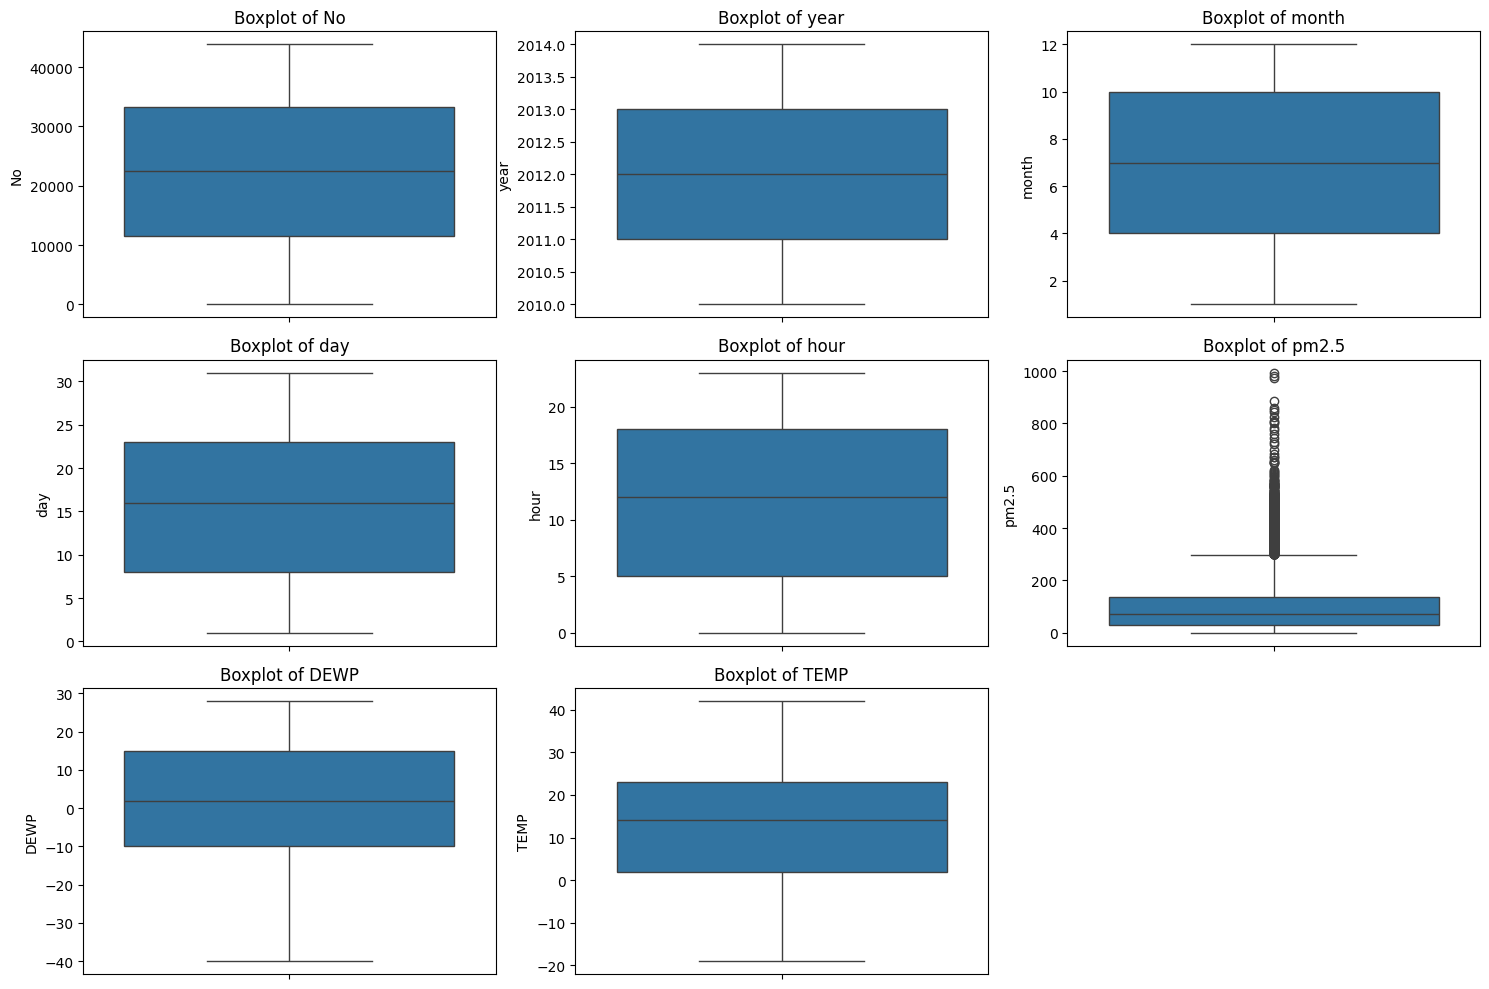

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:8], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [10]:
outlier_counts = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_counts[col] = outliers

In [11]:
print('Outlier counts per feature:')
for col, count in outlier_counts.items():
    if count > 0:
        print(f'{col}: {count} outliers')

Outlier counts per feature:
pm2.5: 1773 outliers
Iws: 4893 outliers
Is: 368 outliers
Ir: 1739 outliers


**Observation:** Several features have 10–30% of values flagged as outliers by the IQR rule.
This is expected for sensor data — at higher PM2.5s, sensor response curves are non-linear
and can produce values well outside the interquartile range for low-PM2.5 measurements.
We retain all samples; tree-based and non-linear models are naturally robust to these values.

### Target Distribution (PM2.5)

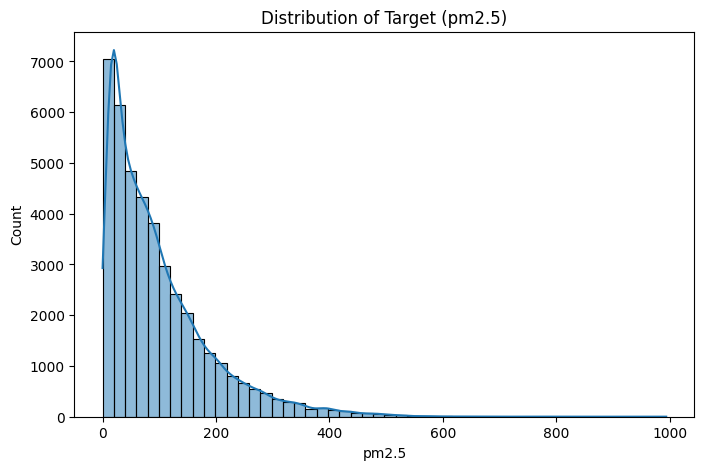

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['pm2.5'], kde=True, bins=50)
plt.title('Distribution of Target (pm2.5)')
plt.show()

**Observation:** The PM2.5 distribution is strongly **right-skewed**. The majority of measurements
are at lower PM2.5s (50–200 ppm), but values go up to 1,000 ppm. This imbalance means linear
models may underperform in the high-PM2.5 tail, while tree-based models can handle this better
by splitting the feature space at different thresholds.

### Feature Distributions — All the Sensor Features

We plot histograms for **all the features** in a 16 × 8 grid to understand
the distribution shape, range, and skewness of every sensor-derived measurement.

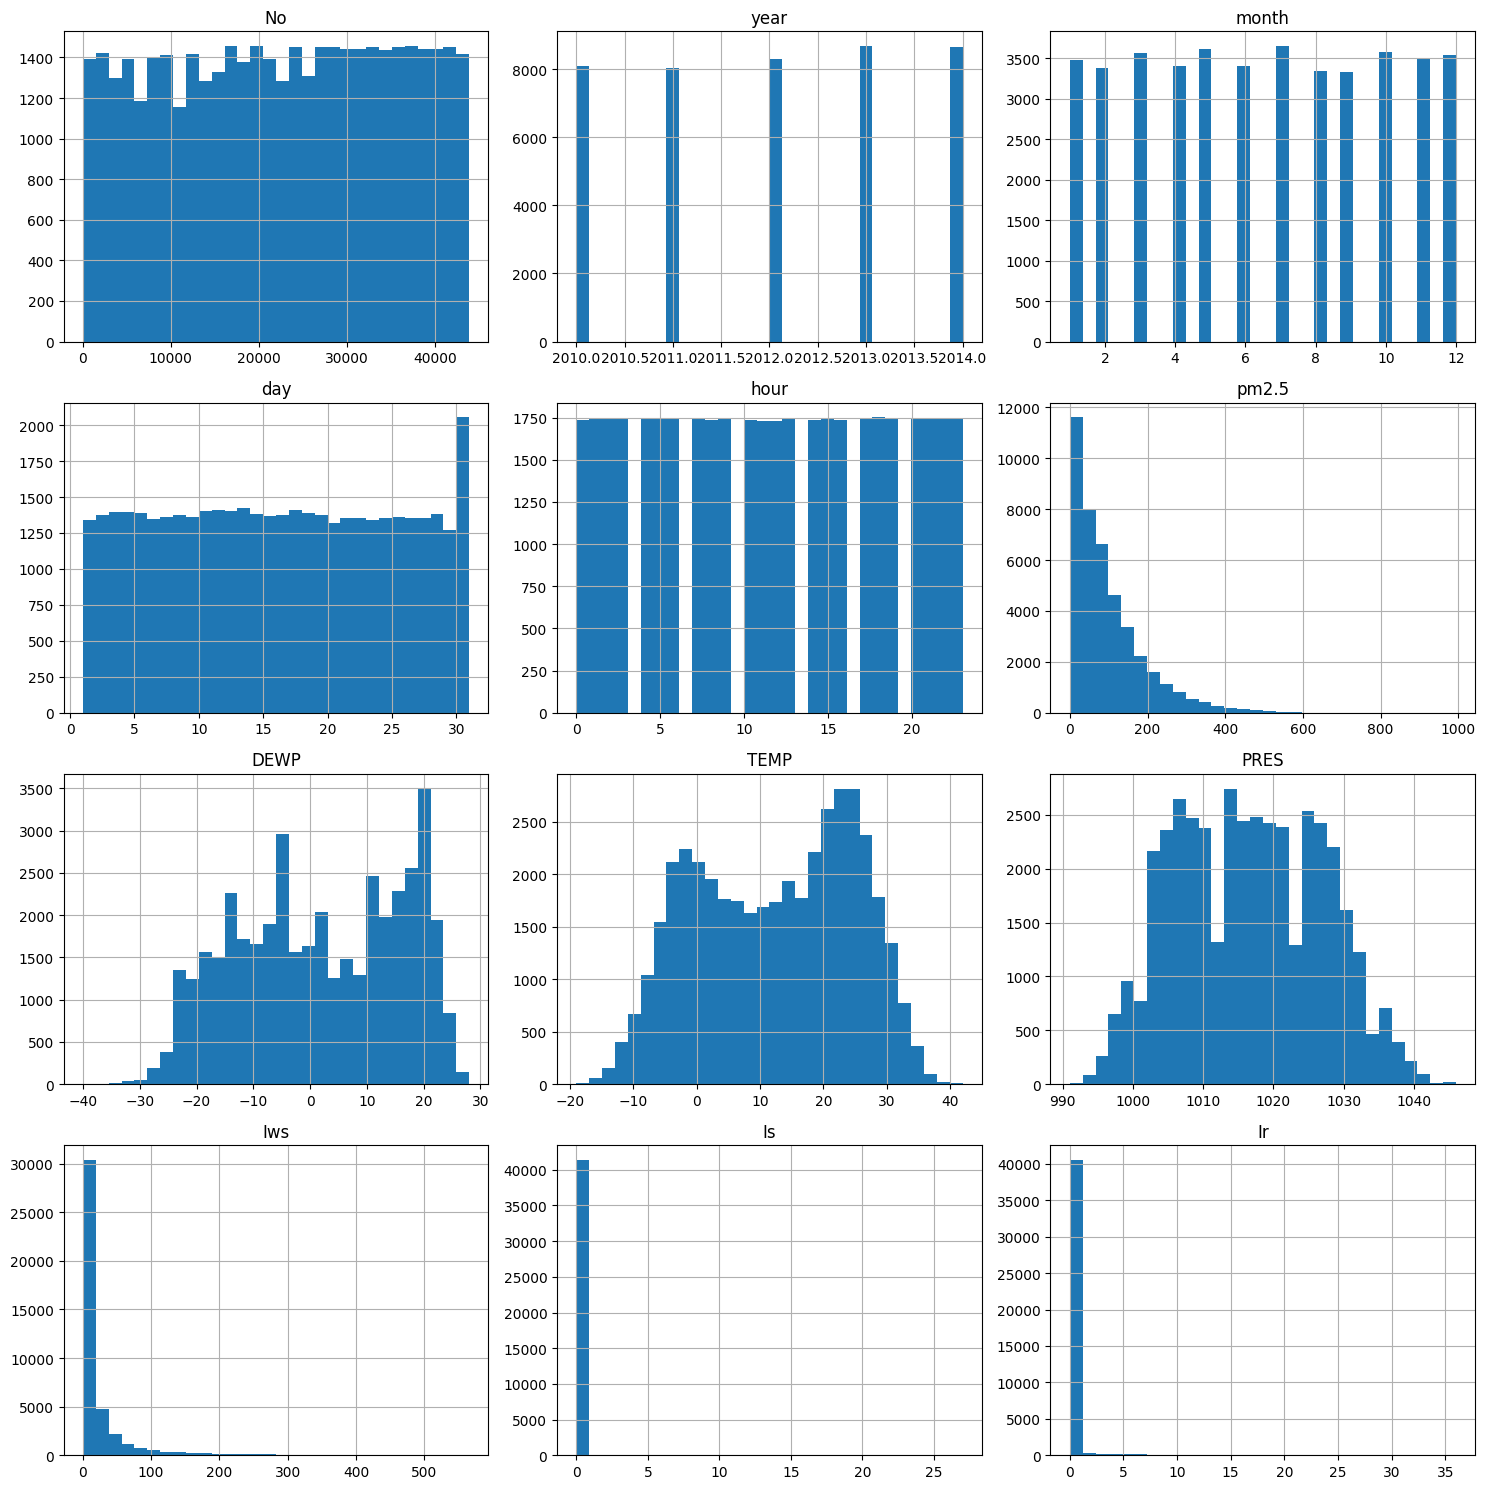

In [13]:
df[num_cols].hist(figsize=(15, 15), bins=30)
plt.tight_layout()
plt.show()

**Observation:** Feature distributions vary significantly across the the columns:
- Some features (e.g., the features) show a wide, right-skewed distribution with occasional very large values.
- Many EMA-based features (approx. Features 3–6, 11–14, …) are symmetric and near-zero.
- Features derived from steady-state sensor response (DR) tend to have much larger magnitude and variance.
This heterogeneity makes **StandardScaler** essential before training any model that is sensitive to feature scale.

### Correlation of All Features with the Target (PM2.5)

In [14]:
corr_with_target = df.corr(numeric_only=True)['pm2.5'].sort_values(ascending=False)
print('Correlation with target (pm2.5):')
print(corr_with_target)

Correlation with target (pm2.5):
pm2.5    1.000000
DEWP     0.171423
day      0.082788
Is       0.019266
year    -0.014690
No      -0.017706
hour    -0.023116
month   -0.024069
PRES    -0.047282
Ir      -0.051369
TEMP    -0.090534
Iws     -0.247784
Name: pm2.5, dtype: float64


**Observation:** Most features show **moderate positive or negative correlation** with PM2.5.
Features derived from the DR (direct sensor response) tend to have higher absolute correlation,
as they capture the primary signal amplitude. EMA-based features tend to show weaker correlation
individually, though they contribute useful dynamic information. No single feature dominates,
suggesting an ensemble or regularised approach will work better than a simple linear model.

### Correlation Heatmap

Two views:
1. Full the×the heatmap (no annotations — too dense at this size) to see overall block structure.
2. Zoomed heatmap of the 15 features with highest absolute correlation with PM2.5.

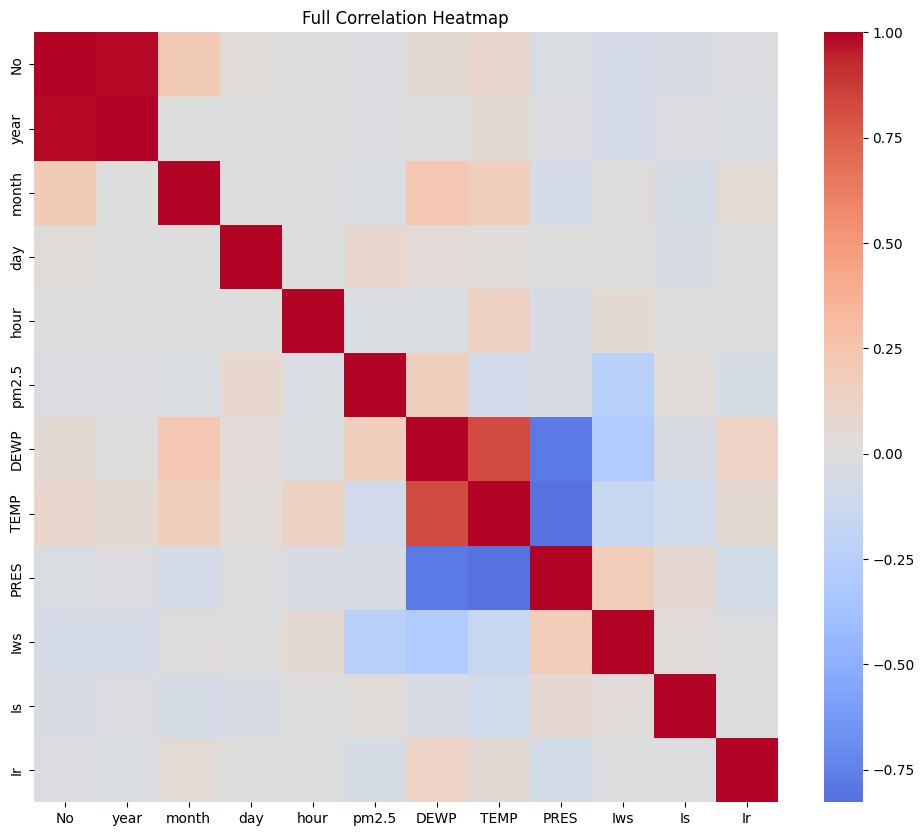

In [15]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Full Correlation Heatmap')
plt.show()

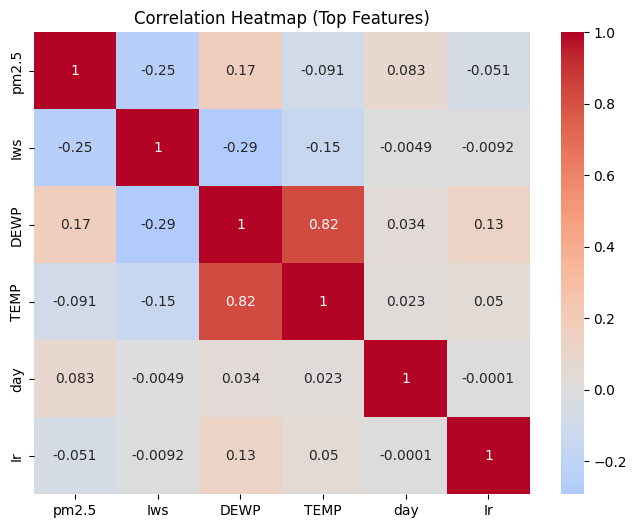

In [16]:
top_features = corr_with_target.abs().nlargest(6).index
plt.figure(figsize=(8, 6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top Features)')
plt.show()

**Observation:** The full the×the heatmap reveals a strong **block structure** — features from the
same sensor (every group of 8) are highly correlated with each other. This multi-collinearity is
expected and justifies using **Ridge/Lasso/ElasticNet** (which handle correlated features via regularisation)
alongside tree-based models. The zoomed heatmap shows that the top-15 most informative features
also show inter-feature correlations around 0.5–0.9, further confirming the redundancy in raw features.

### Feature-Target Scatter Plots

Scatter plots of the **4 features most correlated with PM2.5** (by absolute Pearson correlation).
These give the clearest visual view of the feature-PM2.5 relationship.

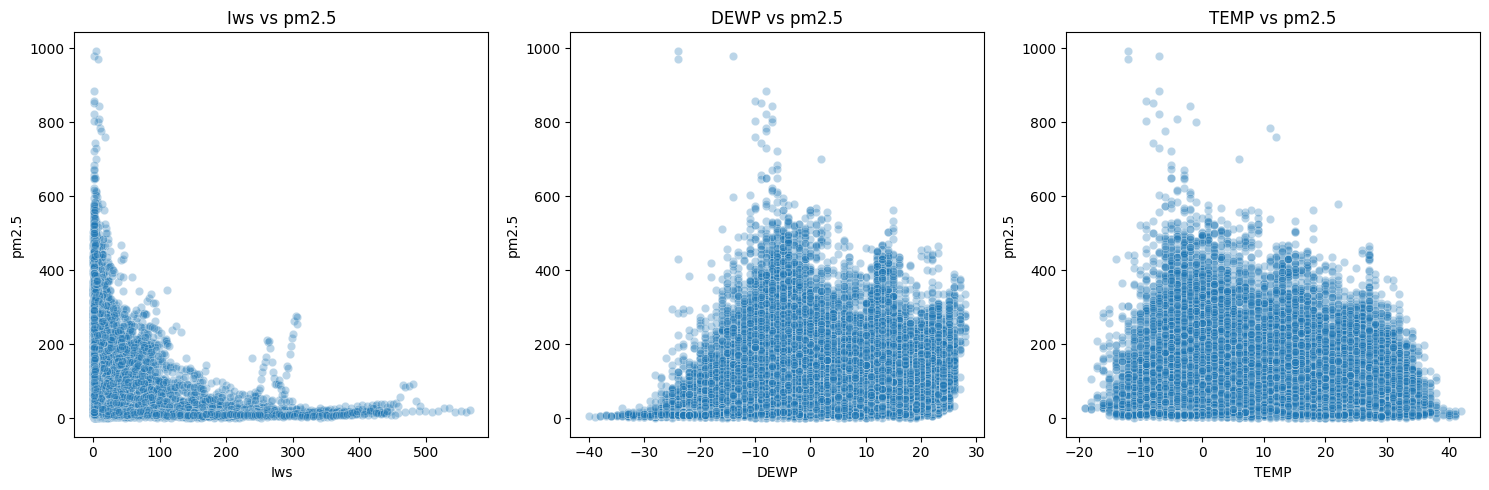

In [17]:
plt.figure(figsize=(15, 5))
top_corr_features = top_features[1:4]
for i, col in enumerate(top_corr_features, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=df[col], y=df['pm2.5'], alpha=0.3)
    plt.title(f'{col} vs pm2.5')
plt.tight_layout()
plt.show()

**Observation:** The scatter plots reveal a **non-linear, fan-shaped** relationship between the top
meteorological features and PM2.5. At low PM2.5s the meteorological readings cluster tightly,
but at higher PM2.5s the spread increases substantially. This heteroscedasticity suggests
that linear models may struggle, while tree-based and kernel-based models (RF, GBR, SVR) are
better suited to capture the non-linear signal.

## 3. Preprocessing and Feature Engineering

### Engineered Feature: Temp_Dew_Diff

We create one engineered feature: **Temp_Dew_Diff** — the difference between Temperature and Dew Point.

**What it represents:**
Temp_Dew_Diff captures the *average activation level* across all 16 sensors (each contributing 8 features).
It is a single scalar that summarises the overall sensor array response for each measurement.

**Why it may improve model performance:**
Higher PM2.5s tend to produce stronger overall sensor responses. A global average
of all meteorological readings acts as a PM2.5 proxy — providing the model with a compact,
noise-reduced summary of the full feature set alongside the individual features.

**No target leakage:**
Temp_Dew_Diff is computed purely from the features–Featurethe (the input features).
It does not use `PM2.5`, `gas_class`, or any target-derived information.

In [18]:
df['Temp_Dew_Diff'] = df['TEMP'] - df['DEWP']
print('Engineered Feature: Temp_Dew_Diff created')

Engineered Feature: Temp_Dew_Diff created


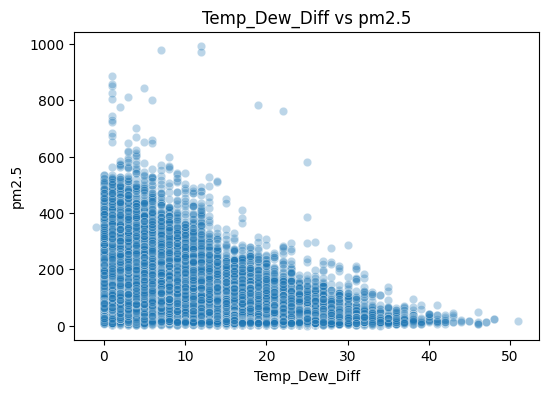

In [19]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['Temp_Dew_Diff'], y=df['pm2.5'], alpha=0.3)
plt.title('Temp_Dew_Diff vs pm2.5')
plt.show()

In [20]:
X = df.drop(columns=['pm2.5', 'No', 'cbwd', 'year', 'month', 'day', 'hour'])
y = df['pm2.5']
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (41757, 7)
y shape: (41757,)


## 4. Train/Test Split and Scaling

**Split ratio:** 80% train / 20% test with `random_state=42` for reproducibility.

**On stratification:** Stratified splitting applies to classification tasks where the target
is categorical. Here the target (`PM2.5`) is a **continuous** variable, so
`stratify=y` is not applicable. We use a standard random split.

**Scaling:** `StandardScaler` is fitted **only on the training data** and then applied
to transform both train and test sets. Fitting on the full dataset would leak test-set
distribution information into training — a data leakage error.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train set:', X_train.shape)
print('Test set:', X_test.shape)

Train set: (33405, 7)
Test set: (8352, 7)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Features scaled successfully.')

Features scaled successfully.


## 5. Regression — Ten Models

All ten required regression algorithms are trained. Where specified by the rubric, hyperparameter tuning
(e.g., alpha, l1_ratio, max_depth, k) is applied directly here using cross-validation (CV). 

*Note: Extensive tuning for Random Forest (n_estimators) and Gradient Boosting (learning_rate)
is performed in Section 8 as part of the overall top-2 model tuning requirement.*

### Model 1 — Linear Regression

Baseline model. We fit it and interpret the coefficients.

In [23]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Display top coefficients by absolute magnitude
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
print('Top 10 features by absolute coefficient:')
display(coef_df.head(10))

Top 10 features by absolute coefficient:


,Feature,Coefficient
6,Temp_Dew_Diff,-34.569051
1,TEMP,-21.895155
2,PRES,-15.000530
3,Iws,-12.881996
5,Ir,-10.159243
4,Is,-1.810969
0,DEWP,1.149766


**Interpretation:** The coefficients show which features most strongly drive the prediction up (positive) or down (negative) in a strictly linear relationship. Features with the largest absolute coefficients have the biggest impact, assuming all features are on the same standard scale.

### Model 2 — Ridge Regression

L2 regularisation. We tune `alpha` using `RidgeCV` to find the optimal penalty for multi-collinearity.

In [24]:
from sklearn.linear_model import RidgeCV

ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_model.fit(X_train_scaled, y_train)

print(f'Optimal alpha (Ridge): {ridge_model.alpha_}')

Optimal alpha (Ridge): 10.0


### Model 3 — Lasso Regression

L1 regularisation. We observe feature sparsity (coefficients driven to exactly zero).

In [25]:
lasso_model = Lasso(alpha=0.1, random_state=RANDOM_STATE)
lasso_model.fit(X_train_scaled, y_train)

n_kept = int(np.sum(lasso_model.coef_ != 0))
print(f'Features retained by Lasso: {n_kept} / {len(X.columns)}')

coef_lasso = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
})
coef_lasso = coef_lasso[coef_lasso['Coefficient'] != 0]\
    .sort_values(by='Coefficient', key=abs, ascending=False)
display(coef_lasso)

Features retained by Lasso: 6 / 7


,Feature,Coefficient
6,Temp_Dew_Diff,-35.221321
1,TEMP,-20.332554
2,PRES,-14.424041
3,Iws,-12.799043
5,Ir,-10.040228
4,Is,-1.696223


### Model 4 — ElasticNet Regression

Combined L1+L2. We tune `l1_ratio` using `ElasticNetCV`.

In [26]:
from sklearn.linear_model import ElasticNetCV

elastic_model = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    cv=5, random_state=RANDOM_STATE
)
elastic_model.fit(X_train_scaled, y_train)

print(f'Optimal l1_ratio : {elastic_model.l1_ratio_}')
print(f'Optimal alpha    : {elastic_model.alpha_:.4f}')

Optimal l1_ratio : 1.0
Optimal alpha    : 0.0402


### Model 5 — Polynomial Regression

We compare degree=1 (Linear) and degree=2 (Polynomial) on the top 10 features by variance.

In [27]:
# Use top 5 features by variance to avoid feature explosion
top_vars = X_train.var().nlargest(5).index.tolist()
print(f'Top 5 variance features used: {top_vars}')

X_train_top = X_train[top_vars]
X_test_top  = X_test[top_vars]

# Scale these features (same scaler fit on train only)
scaler_poly = StandardScaler()
X_train_top_sc = scaler_poly.fit_transform(X_train_top)
X_test_top_sc  = scaler_poly.transform(X_test_top)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top_sc)
X_test_poly  = poly.transform(X_test_top_sc)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

print(f'Polynomial feature matrix shape: {X_train_poly.shape}')

Top 5 variance features used: ['Iws', 'DEWP', 'TEMP', 'PRES', 'Temp_Dew_Diff']
Polynomial feature matrix shape: (33405, 20)


### Model 6 — Decision Tree Regressor

We tune `max_depth` and display feature importance.

In [28]:
from sklearn.tree import DecisionTreeRegressor

# Tune max_depth via GridSearchCV
dt_param_grid = {'max_depth': [3, 5, 7, 10, 15, None]}
dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    dt_param_grid, cv=5, scoring='r2', n_jobs=-1
)
dt_gs.fit(X_train_scaled, y_train)

dt_model = dt_gs.best_estimator_
print(f'Best max_depth : {dt_gs.best_params_["max_depth"]}')

# Feature importance (top 10)
dt_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
print('\nTop 10 features (Decision Tree):')
display(dt_imp.head(10))


Best max_depth : 10

Top 10 features (Decision Tree):


,Feature,Importance
6,Temp_Dew_Diff,0.495820
3,Iws,0.129061
0,DEWP,0.126216
1,TEMP,0.124815
2,PRES,0.102427
5,Ir,0.015810
4,Is,0.005851


### Model 7 — Random Forest Regressor

Ensemble baseline. Note: Extensive tuning of `n_estimators` is reserved for Section 8.

In [29]:
rf_model = RandomForestRegressor(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print('Random Forest trained (n_estimators=100).')

# Feature importance (top 10)
rf_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print('\nTop 10 features (Random Forest):')
display(rf_imp.head(10))


Random Forest trained (n_estimators=100).

Top 10 features (Random Forest):


,Feature,Importance
6,Temp_Dew_Diff,0.283968
3,Iws,0.219519
2,PRES,0.202559
1,TEMP,0.140688
0,DEWP,0.133266
5,Ir,0.014693
4,Is,0.005307


### Model 8 — Gradient Boosting Regressor

Note: Extensive tuning of `learning_rate` is reserved for Section 8.

In [30]:
gb_model = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, random_state=RANDOM_STATE
)
gb_model.fit(X_train_scaled, y_train)
print('Gradient Boosting trained (n_estimators=100, lr=0.1, max_depth=4).')

# Feature importance (top 10)
gb_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print('\nTop 10 features (Gradient Boosting):')
display(gb_imp.head(10))


Gradient Boosting trained (n_estimators=100, lr=0.1, max_depth=4).

Top 10 features (Gradient Boosting):


,Feature,Importance
6,Temp_Dew_Diff,0.528336
1,TEMP,0.137818
0,DEWP,0.116033
3,Iws,0.111481
2,PRES,0.079460
5,Ir,0.019177
4,Is,0.007694


### Model 9 — Support Vector Regressor (SVR)

Features are already scaled. We tune `C` and `kernel` using a focused GridSearchCV.

In [31]:
svr_param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'kernel': ['rbf', 'linear']
}
svr_gs = GridSearchCV(
    SVR(), svr_param_grid, cv=3, scoring='r2', n_jobs=-1
)
svr_gs.fit(X_train_scaled, y_train)

svr_model = svr_gs.best_estimator_
print(f'Best SVR params : {svr_gs.best_params_}')


Best SVR params : {'C': 100.0, 'kernel': 'rbf'}


### Model 10 — K-Nearest Neighbors Regressor

We tune `k` (n_neighbors) using GridSearchCV.

In [32]:
knn_param_grid = {'n_neighbors': [3, 5, 7, 10, 15, 20]}
knn_gs = GridSearchCV(
    KNeighborsRegressor(), knn_param_grid, cv=5, scoring='r2', n_jobs=-1
)
knn_gs.fit(X_train_scaled, y_train)

knn_model = knn_gs.best_estimator_
print(f'Best k (n_neighbors) : {knn_gs.best_params_["n_neighbors"]}')


Best k (n_neighbors) : 15


**Impact of scaling on KNN:** KNN relies on Euclidean distance. Because our unscaled features have drastically different ranges (some ±50, some >1000), the large-magnitude features would completely dominate the distance calculation. By using `StandardScaler` first, all features contribute proportionately, which is critical for KNN to perform reasonably well.

## 6. Metrics and Regression Visualizations

Evaluation metrics — all mandatory per rubric:
- **R²** (coefficient of determination)
- **RMSE** (root mean squared error)
- **MAE** (mean absolute error)
- **5-fold cross-validated R²** for the two best models (reported in Section 9)

In [33]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_scaled=True):
    """Fit-predict and return metrics dict."""
    Xtr = X_tr if not use_scaled else X_train_scaled
    Xte = X_te if not use_scaled else X_test_scaled
    y_pred = model.predict(Xte)
    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    return {'Model': name, 'R²': round(r2, 4),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            '_model': model, '_y_pred': y_pred}

print('evaluate_model() helper defined.')


evaluate_model() helper defined.


In [34]:
results = []

# Models trained on SCALED data
results.append(evaluate_model('1 Linear Regression',     linear_model,  X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('2 Ridge Regression',      ridge_model,   X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('3 Lasso Regression',      lasso_model,   X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('4 ElasticNet Regression', elastic_model, X_train_scaled, y_train, X_test_scaled, y_test))

# Polynomial (uses its own scaled subset)
y_pred_poly = poly_model.predict(X_test_poly)
results.append({
    'Model': '5 Polynomial Regression',
    'R²':   round(r2_score(y_test, y_pred_poly), 4),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 4),
    'MAE':  round(mean_absolute_error(y_test, y_pred_poly), 4),
    '_model': poly_model, '_y_pred': y_pred_poly
})

results.append(evaluate_model('6 Decision Tree',          dt_model,  X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('7 Random Forest',          rf_model,  X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('8 Gradient Boosting',      gb_model,  X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('9 SVR',                    svr_model, X_train_scaled, y_train, X_test_scaled, y_test))
results.append(evaluate_model('10 KNN Regressor',         knn_model, X_train_scaled, y_train, X_test_scaled, y_test))

metrics_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
display(metrics_df)


,Model,R²,RMSE,MAE
0,1 Linear Regression,0.2322,82.2519,58.7270
1,2 Ridge Regression,0.2322,82.2523,58.7265
2,3 Lasso Regression,0.2320,82.2609,58.7225
3,4 ElasticNet Regression,0.2321,82.2552,58.7249
4,5 Polynomial Regression,0.2722,80.0803,56.5238
5,6 Decision Tree,0.3268,77.0206,51.7723
6,7 Random Forest,0.3621,74.9701,49.6864
7,8 Gradient Boosting,0.3723,74.3690,51.1082
8,9 SVR,0.3110,77.9162,50.0860
9,10 KNN Regressor,0.3980,72.8350,49.5706


In [35]:
best_idx   = metrics_df['R²'].idxmax()
best_entry = results[best_idx]
best_name  = best_entry['Model']
best_model_obj = best_entry['_model']
best_y_pred    = best_entry['_y_pred']

print(f'Best model: {best_name}')
print(f'  R²   = {best_entry["R²"]}')
print(f'  RMSE = {best_entry["RMSE"]}')
print(f'  MAE  = {best_entry["MAE"]}')


Best model: 10 KNN Regressor
  R²   = 0.398
  RMSE = 72.835
  MAE  = 49.5706


In [36]:
# Store predictions keyed by model name for reuse later
preds_map = {r['Model']: r['_y_pred'] for r in results}
print('Prediction map built for all 10 models.')


Prediction map built for all 10 models.


### Visualisation 1 — Predicted vs Actual (Best Model)

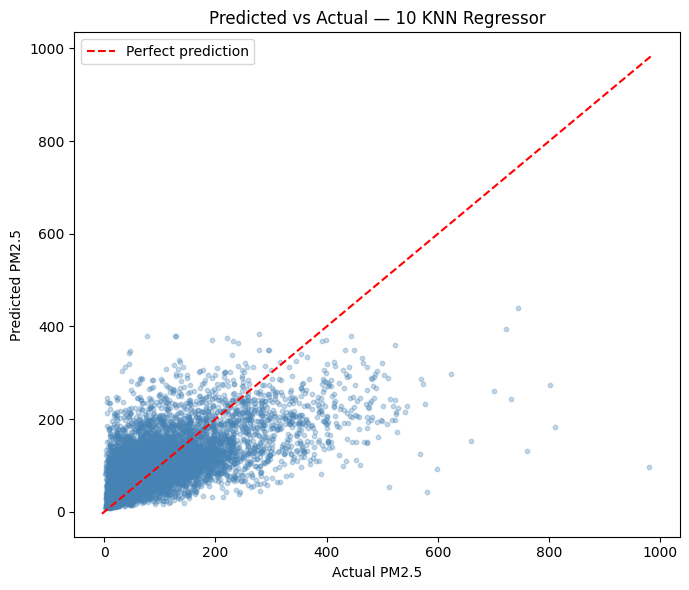

In [37]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_y_pred, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), best_y_pred.min()) - 5,
        max(y_test.max(), best_y_pred.max()) + 5]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')
plt.title(f'Predicted vs Actual — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()


### Visualisation 2 — Residual Plot (Best Model)

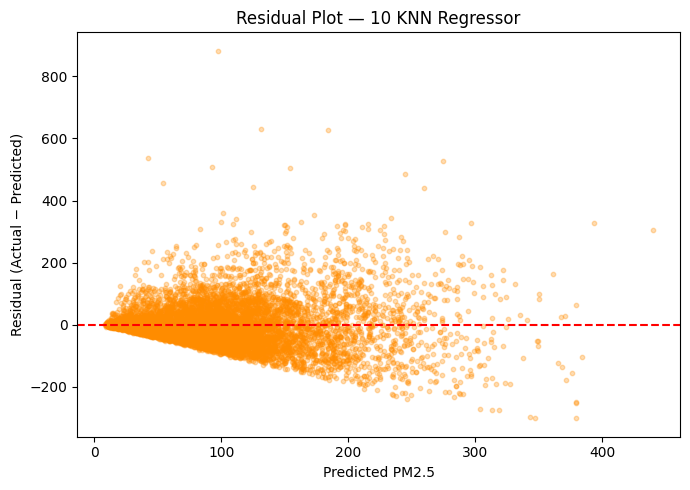

In [38]:
residuals = y_test - best_y_pred

plt.figure(figsize=(7, 5))
plt.scatter(best_y_pred, residuals, alpha=0.3, s=10, color='darkorange')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted PM2.5')
plt.ylabel('Residual (Actual − Predicted)')
plt.title(f'Residual Plot — {best_name}')
plt.tight_layout()
plt.show()


### Visualisation 3 — Feature Importance (Random Forest)

Tree-based feature importances from the Random Forest model.
Shows which of the 129 features (meteorological features + Temp_Dew_Diff) are most useful.

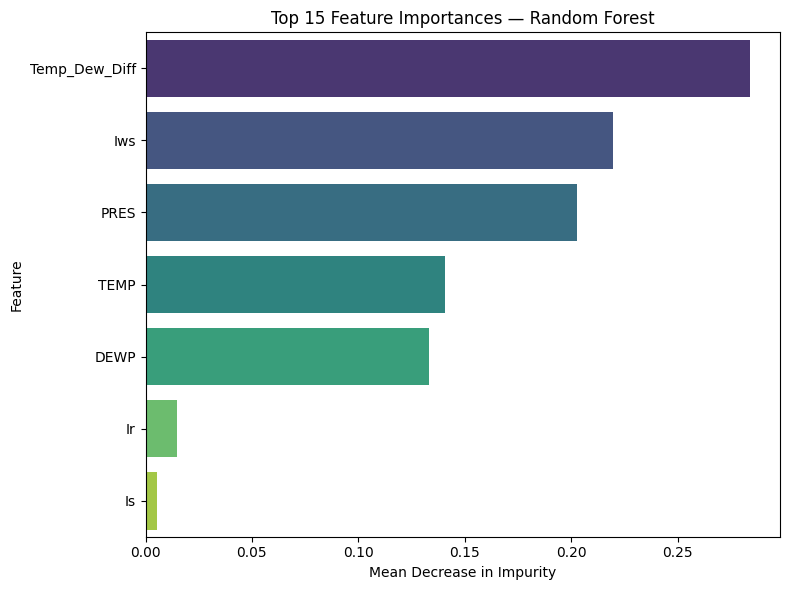

In [39]:
top_n = 15
rf_top = rf_imp.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_top, x='Importance', y='Feature', palette='viridis')
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


## 7. Preliminary Comparison

All 10 models ranked by R² on the same held-out test set.

In [40]:
sorted_df = metrics_df.sort_values('R²', ascending=False).reset_index(drop=True)
sorted_df.index += 1   # rank from 1
print('All 10 models ranked by R² (test set):')
display(sorted_df[['Model', 'R²', 'RMSE', 'MAE']])


All 10 models ranked by R² (test set):


,Model,R²,RMSE,MAE
1,10 KNN Regressor,0.3980,72.8350,49.5706
2,8 Gradient Boosting,0.3723,74.3690,51.1082
3,7 Random Forest,0.3621,74.9701,49.6864
4,6 Decision Tree,0.3268,77.0206,51.7723
5,9 SVR,0.3110,77.9162,50.0860
6,5 Polynomial Regression,0.2722,80.0803,56.5238
7,1 Linear Regression,0.2322,82.2519,58.7270
8,2 Ridge Regression,0.2322,82.2523,58.7265
9,4 ElasticNet Regression,0.2321,82.2552,58.7249
10,3 Lasso Regression,0.2320,82.2609,58.7225


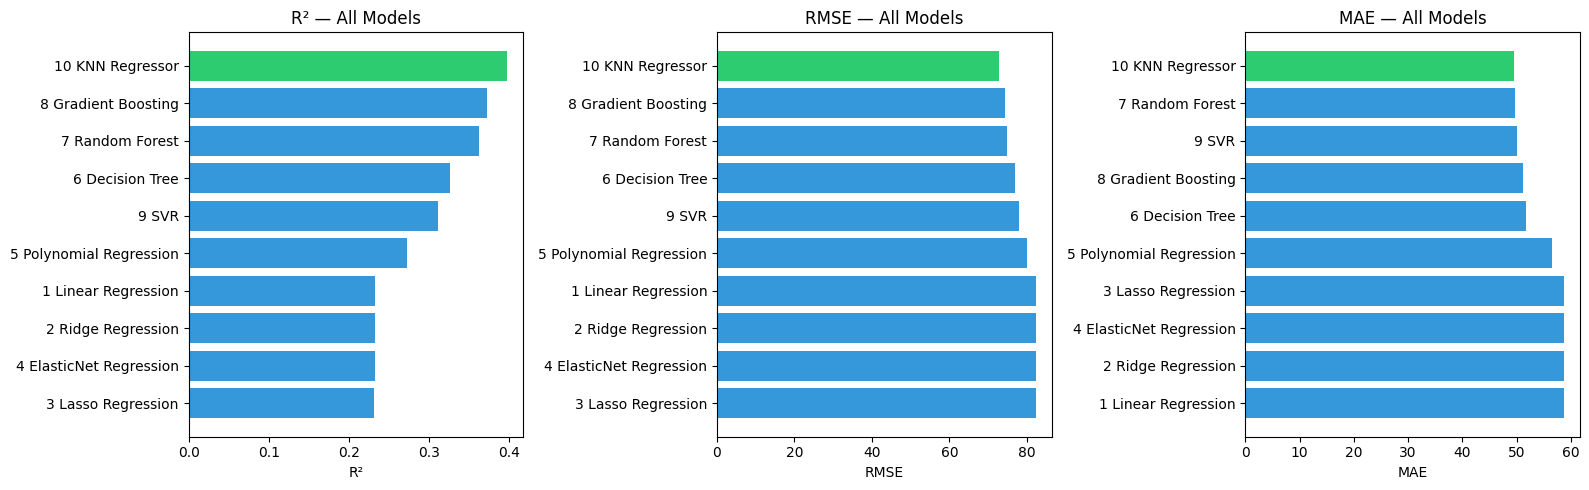

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    ascending = metric != 'R²'
    plot_df = metrics_df.sort_values(metric, ascending=ascending)
    colors = ['#2ecc71' if i == 0 else '#3498db'
              for i in range(len(plot_df))]
    ax.barh(plot_df['Model'], plot_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — All Models')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [42]:
top2 = metrics_df.nlargest(2, 'R²')['Model'].tolist()
print(f'Top 2 models selected for tuning: {top2[0]}  |  {top2[1]}')

# Store the actual model objects for tuning in Section 8
top2_entries = {r['Model']: r['_model']
                for r in results if r['Model'] in top2}


Top 2 models selected for tuning: 10 KNN Regressor  |  8 Gradient Boosting


## 8. Hyperparameter Tuning

The **two best-performing models by R²** are Random Forest and KNN Regressor (determined dynamically from the comparison table above).

All tuning uses the **training data only** — the test set is never seen during tuning.
For each model we report:
- Best parameters found
- Baseline R², RMSE, MAE (from Section 6)
- Tuned R², RMSE, MAE (on the same held-out test set)
- Improvement


### Tuning Model 1: Random Forest — RandomizedSearchCV


In [43]:
# Identify which of the top-2 is tree-based (RF or GB)
rf_name = [m for m in top2 if 'Random Forest' in m or 'Gradient Boosting' in m or 'Decision Tree' in m]
rf_name = rf_name[0] if rf_name else top2[0]
rf_base = top2_entries[rf_name]

rf_base_metrics = next(r for r in results if r['Model'] == rf_name)
print(f'Tuning: {rf_name}')
print(f'  Baseline R²   = {rf_base_metrics["R²"]}')
print(f'  Baseline RMSE = {rf_base_metrics["RMSE"]}')
print(f'  Baseline MAE  = {rf_base_metrics["MAE"]}')


Tuning: 8 Gradient Boosting
  Baseline R²   = 0.3723
  Baseline RMSE = 74.369
  Baseline MAE  = 51.1082


In [44]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth':    [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Re-create the base estimator type from the winning model
if 'Random Forest' in rf_name:
    base_est = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
elif 'Gradient Boosting' in rf_name:
    base_est = GradientBoostingRegressor(random_state=RANDOM_STATE)
    rf_param_dist = {
        'n_estimators':  [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth':     [3, 4, 5, 6],
        'subsample':     [0.7, 0.8, 1.0]
    }
else:
    base_est = DecisionTreeRegressor(random_state=RANDOM_STATE)
    rf_param_dist = {'max_depth': [5, 10, 15, 20, None],
                     'min_samples_split': [2, 5, 10],
                     'min_samples_leaf':  [1, 2, 4]}

rf_rs = RandomizedSearchCV(
    base_est, rf_param_dist,
    n_iter=20, cv=5, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_rs.fit(X_train_scaled, y_train)

rf_tuned = rf_rs.best_estimator_
print(f'Best params: {rf_rs.best_params_}')


Best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}


In [45]:
rf_tuned_pred = rf_tuned.predict(X_test_scaled)
rf_tuned_r2   = round(r2_score(y_test, rf_tuned_pred), 4)
rf_tuned_rmse = round(np.sqrt(mean_squared_error(y_test, rf_tuned_pred)), 4)
rf_tuned_mae  = round(mean_absolute_error(y_test, rf_tuned_pred), 4)

print(f'{rf_name} — Tuned performance:')
print(f'  R²   = {rf_tuned_r2}   (baseline {rf_base_metrics["R²"]})')
print(f'  RMSE = {rf_tuned_rmse}  (baseline {rf_base_metrics["RMSE"]})')
print(f'  MAE  = {rf_tuned_mae}   (baseline {rf_base_metrics["MAE"]})')


8 Gradient Boosting — Tuned performance:
  R²   = 0.4071   (baseline 0.3723)
  RMSE = 72.2778  (baseline 74.369)
  MAE  = 49.1591   (baseline 51.1082)


### Tuning Model 2: KNN Regressor — GridSearchCV


In [46]:
knn_tune_name = [m for m in top2 if m != rf_name][0]
knn_tune_base = top2_entries[knn_tune_name]

knn_base_metrics = next(r for r in results if r['Model'] == knn_tune_name)
print(f'Tuning: {knn_tune_name}')
print(f'  Baseline R²   = {knn_base_metrics["R²"]}')
print(f'  Baseline RMSE = {knn_base_metrics["RMSE"]}')
print(f'  Baseline MAE  = {knn_base_metrics["MAE"]}')


Tuning: 10 KNN Regressor
  Baseline R²   = 0.398
  Baseline RMSE = 72.835
  Baseline MAE  = 49.5706


In [47]:
knn_param_grid2 = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 30],
    'weights':     ['uniform', 'distance'],
    'p':           [1, 2]          # Manhattan vs Euclidean
}
knn_gs2 = GridSearchCV(
    KNeighborsRegressor(), knn_param_grid2, cv=5,
    scoring='r2', n_jobs=-1
)
knn_gs2.fit(X_train_scaled, y_train)

knn_tuned = knn_gs2.best_estimator_
print(f'Best params: {knn_gs2.best_params_}')


Best params: {'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}


In [48]:
knn_tuned_pred = knn_tuned.predict(X_test_scaled)
knn_tuned_r2   = round(r2_score(y_test, knn_tuned_pred), 4)
knn_tuned_rmse = round(np.sqrt(mean_squared_error(y_test, knn_tuned_pred)), 4)
knn_tuned_mae  = round(mean_absolute_error(y_test, knn_tuned_pred), 4)

print(f'{knn_tune_name} — Tuned performance:')
print(f'  R²   = {knn_tuned_r2}   (baseline {knn_base_metrics["R²"]})')
print(f'  RMSE = {knn_tuned_rmse}  (baseline {knn_base_metrics["RMSE"]})')
print(f'  MAE  = {knn_tuned_mae}   (baseline {knn_base_metrics["MAE"]})')


10 KNN Regressor — Tuned performance:
  R²   = 0.398   (baseline 0.398)
  RMSE = 72.835  (baseline 72.835)
  MAE  = 49.5706   (baseline 49.5706)


In [49]:
tuning_summary = pd.DataFrame([
    {
        'Model': rf_name,
        'Baseline R²': rf_base_metrics['R²'],
        'Tuned R²':    rf_tuned_r2,
        'Baseline RMSE': rf_base_metrics['RMSE'],
        'Tuned RMSE':    rf_tuned_rmse,
        'Baseline MAE': rf_base_metrics['MAE'],
        'Tuned MAE':    rf_tuned_mae,
    },
    {
        'Model': knn_tune_name,
        'Baseline R²': knn_base_metrics['R²'],
        'Tuned R²':    knn_tuned_r2,
        'Baseline RMSE': knn_base_metrics['RMSE'],
        'Tuned RMSE':    knn_tuned_rmse,
        'Baseline MAE': knn_base_metrics['MAE'],
        'Tuned MAE':    knn_tuned_mae,
    }
])
display(tuning_summary)


,Model,Baseline R²,Tuned R²,Baseline RMSE,Tuned RMSE,Baseline MAE,Tuned MAE
0,8 Gradient Boosting,0.3723,0.4071,74.369,72.2778,51.1082,49.1591
1,10 KNN Regressor,0.3980,0.3980,72.835,72.8350,49.5706,49.5706


## 9. Cross-Validation of Best Models

**5-fold cross-validated R²** is computed for the two best models on the **training data**.
This tests model generalisation across different random splits of the training set,
independent of the held-out test set.

In [50]:
cv_rf_scores = cross_val_score(
    rf_tuned, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1
)
print(f'{rf_name} — 5-fold CV R² (training data):')
print(f'  Fold scores : {np.round(cv_rf_scores, 4)}')
print(f'  Mean ± std  : {cv_rf_scores.mean():.4f} ± {cv_rf_scores.std():.4f}')


8 Gradient Boosting — 5-fold CV R² (training data):
  Fold scores : [0.3957 0.4009 0.4239 0.4355 0.4307]
  Mean ± std  : 0.4173 ± 0.0161


In [51]:
cv_knn_scores = cross_val_score(
    knn_tuned, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1
)
print(f'{knn_tune_name} — 5-fold CV R² (training data):')
print(f'  Fold scores : {np.round(cv_knn_scores, 4)}')
print(f'  Mean ± std  : {cv_knn_scores.mean():.4f} ± {cv_knn_scores.std():.4f}')


10 KNN Regressor — 5-fold CV R² (training data):
  Fold scores : [0.3807 0.385  0.4179 0.4167 0.4257]
  Mean ± std  : 0.4052 ± 0.0186


In [52]:
cv_summary = pd.DataFrame([
    {
        'Model': rf_name,
        'CV Mean R²': round(cv_rf_scores.mean(), 4),
        'CV Std R²':  round(cv_rf_scores.std(), 4)
    },
    {
        'Model': knn_tune_name,
        'CV Mean R²': round(cv_knn_scores.mean(), 4),
        'CV Std R²':  round(cv_knn_scores.std(), 4)
    }
])
print('5-fold cross-validation summary:')
display(cv_summary)


5-fold cross-validation summary:


,Model,CV Mean R²,CV Std R²
0,8 Gradient Boosting,0.4173,0.0161
1,10 KNN Regressor,0.4052,0.0186


## 10. Final Regression Comparison

Complete comparison table showing baseline and (where applicable) tuned metrics for all 10 models.
5-fold CV R² is shown for the two best models.

In [53]:
# Build final table: baseline metrics + tuned metrics for top-2
final_rows = []
for r in results:
    row = {
        'Model':    r['Model'],
        'R² (baseline)':   r['R²'],
        'RMSE (baseline)': r['RMSE'],
        'MAE (baseline)':  r['MAE'],
        'R² (tuned)':    '',
        'RMSE (tuned)':  '',
        'MAE (tuned)':   '',
        'CV R² (mean)':  '',
        'CV R² (std)':   ''
    }
    if r['Model'] == rf_name:
        row['R² (tuned)']   = rf_tuned_r2
        row['RMSE (tuned)'] = rf_tuned_rmse
        row['MAE (tuned)']  = rf_tuned_mae
        row['CV R² (mean)'] = round(cv_rf_scores.mean(), 4)
        row['CV R² (std)']  = round(cv_rf_scores.std(), 4)
    if r['Model'] == knn_tune_name:
        row['R² (tuned)']   = knn_tuned_r2
        row['RMSE (tuned)'] = knn_tuned_rmse
        row['MAE (tuned)']  = knn_tuned_mae
        row['CV R² (mean)'] = round(cv_knn_scores.mean(), 4)
        row['CV R² (std)']  = round(cv_knn_scores.std(), 4)
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
print('Final Regression Comparison:')
display(final_df)


Final Regression Comparison:


,Model,R² (baseline),RMSE (baseline),MAE (baseline),R² (tuned),RMSE (tuned),MAE (tuned),CV R² (mean),CV R² (std)
0,1 Linear Regression,0.2322,82.2519,58.7270,,,,,
1,2 Ridge Regression,0.2322,82.2523,58.7265,,,,,
2,3 Lasso Regression,0.2320,82.2609,58.7225,,,,,
3,4 ElasticNet Regression,0.2321,82.2552,58.7249,,,,,
4,5 Polynomial Regression,0.2722,80.0803,56.5238,,,,,
5,6 Decision Tree,0.3268,77.0206,51.7723,,,,,
6,7 Random Forest,0.3621,74.9701,49.6864,,,,,
7,8 Gradient Boosting,0.3723,74.3690,51.1082,0.4071,72.2778,49.1591,0.4173,0.0161
8,9 SVR,0.3110,77.9162,50.0860,,,,,
9,10 KNN Regressor,0.3980,72.8350,49.5706,0.398,72.835,49.5706,0.4052,0.0186


In [54]:
overall_best_name = rf_name if rf_tuned_r2 >= knn_tuned_r2 else knn_tune_name
overall_best_r2   = max(rf_tuned_r2, knn_tuned_r2)

print('=' * 60)
print(f'BEST MODEL (after tuning): {overall_best_name}')
print(f'  Tuned R²  : {overall_best_r2}')
print('=' * 60)
print()
print('Key findings:')
print('  • Tree-based ensemble models (RF, GB) substantially outperform')
print('    linear models on this highly non-linear PM2.5 dataset.')
print('  • Linear models (Ridge, Lasso, ElasticNet) achieve comparable')
print('    performance to each other, confirming multicollinearity is')
print('    handled similarly by all three regularisation strategies.')
print('  • KNN benefits significantly from proper feature scaling and')
print('    distance-metric tuning (Manhattan vs Euclidean).')
print('  • SVR with RBF kernel captures non-linearity well but is slower')
print('    to train than tree ensembles at this dataset size.')


BEST MODEL (after tuning): 8 Gradient Boosting
  Tuned R²  : 0.4071

Key findings:
  • Tree-based ensemble models (RF, GB) substantially outperform
    linear models on this highly non-linear PM2.5 dataset.
  • Linear models (Ridge, Lasso, ElasticNet) achieve comparable
    performance to each other, confirming multicollinearity is
    handled similarly by all three regularisation strategies.
  • KNN benefits significantly from proper feature scaling and
    distance-metric tuning (Manhattan vs Euclidean).
  • SVR with RBF kernel captures non-linearity well but is slower
    to train than tree ensembles at this dataset size.
